# Category theory for programmers
## Chapter 1
- Categories have the following 3 important properties:
    1. Objects ($A,B,C ...$) -> for programming these will represent data types
    2. Morphisms ($f,g,h ...$) -> for programming these reflect functions
        - function is defined by the type it takes in and type it spits out (an arrow that moves from point A to point B on the graph)
            - $f$ :: $A \to B$ => takes input of type A and returns type B 
        - functions must be composable so if:
            - $f$ :: $A \to B$
            - $g$ :: $B \to C$
            - then $g \circ f$ :: $A \to C$
                - composition is read right->left takes $A$, applies $f$, then applies $g$
        - must be associative so: $h \circ g \circ h$ == $(h \circ g) \circ f$ == $h \circ (g \circ f)$
    3. Identity morphism ($id_{a} :: a \to a$) -> takes an object and returns that object
        - use lower case for variable types, upper case for concrete types
        - $id$ is also composable
            - $f \circ id_{A} == f$ 
            - $id_{B} \circ f == f$ in both of these compositions returns the function $f$

### Problem Set
1. Implement identity function in python

In [14]:
from typing import Any, TypeVar, ParamSpec, Callable, Union
from inspect import signature
import random

In [2]:
T = TypeVar("T")
R = TypeVar("R")

def id(x:T) -> T:
    return x

def f_func(x:Union[int, Callable]) -> Union[str, Callable]:
    #print("butt")
    try:
        assert isinstance(x,int), "need an int as input"
        return(str(x))
    except: 
        try:
            assert isinstance(x, Callable)
            return(f_func)
        except: return("No acceptable type given")
def g_func(y:Union[str,Callable]) -> Union[float,Callable]:
    #print("boob")
    try:
        assert isinstance(y,str), "need a string as input"
        return(float(y))
    except: 
        try:
            assert isinstance(y, Callable)
            return(g_func)
        except: return("No acceptable type given")
    
print(f_func(6))
print(type(f_func(id(6))))
print(id(f_func))
print(type(f_func(id)))
print(f_func("Chad"))


6
<class 'str'>
<function f_func at 0x108919da0>
<class 'function'>
No acceptable type given


2. Implement a composition function that takes two functions as argument and applies one to the other.

In [16]:
P = ParamSpec("P")

# This allows us to get the return type of some function -> need this to type check composition
def infer_return_type(func: Callable) -> type:
    return func.__annotations__.get('return', None)

# this takes any two functions, confirms output of first is input of second, and returns function composed of both
def composition(func1: Callable[P,T], 
                func2: Callable[T,R]) -> Callable[P,R]:
    #print(infer_return_type(func1))
    siggy = signature(func2)
    arg_types = [param.annotation for param in siggy.parameters.values()]
    for i in arg_types:
        print(i)
    assert ((infer_return_type(func1)) == arg_types[0] or arg_types[0] == T or infer_return_type(func1) == T), "Return of first function does not match input of second function"
    return(lambda x: func2(func1(x)))

h_func = composition(f_func, g_func)
print(h_func(6))
print(type(h_func(6)))

bad_func = composition(g_func, f_func)
print(bad_func(6))

typing.Union[str, typing.Callable]
6.0
<class 'float'>
typing.Union[int, typing.Callable]


AssertionError: Return of first function does not match input of second function

3. Write a program that tests that the composition function respects

In [117]:
# Testing both directions of composition
id_func1 = composition(id,f_func)
id_func2 = composition(f_func,id)

#Testing composition on a composed function (h = g o f)
id_func3 = composition(h_func,id)

print(id_func1(6))
print(id_func2(6))
print(id_func3(6))

6
6
6.0


### Now with Haskell
We can use jupyter notebooks with a haskell kernel as well yippee

In [1]:
identity :: a -> a
identity x = x

--identity 5

fFunc :: Integer -> String
fFunc x = show x

gFunc :: String -> Float
gFunc x  = read x

-- gFunc (fFunc 7)

-- because we take arguments x, y to x.y need to give the type conversion for outer function first
compose :: (b -> c) -> (a -> b) -> (a -> c)
compose x y = x . y

hFunc = compose gFunc fFunc
hFunc 6

iFunc = compose fFunc gFunc 

Line 7: Eta reduce
Found:
fFunc x = show x
Why not:
fFunc = showLine 10: Eta reduce
Found:
gFunc x = read x
Why not:
gFunc = read

6.0

4. Is the web a category? Are links morphisms?
    - Objects? Sites
    - Morphisms? links, take us from one site to the next.
        - composition? in some sense yes, clicking a link takes us to another page with another link which can take us to a third page/ in some other sense no, can't generate a link to take us from page 1 to 3, without changing the links on page 1
    - identity? yes? can have a link to the current page
5. Is facebook a category? -> as a website kinda
    - Objects: People, pages, groups
    - Morphisms: following, friending
        - composition no? in terms of navigating network maybe??????? but friending someone is not necessarilly composable with their friendships
    -  identity: can go to self
6.  When is a directed graph a category?
    - when a node can return to itself (identity) - not a simple directed graph
    - when it is a multigraph (can allow for multiple morphisms between the same objects)


## Chapter 2
Why typing?
- supports pre-run verification of programs by identifying and blocking functions with type-mismatches before runtime
- Typing is for supporting function composability and allows us to verify before run-time that a program will run
    - typing mismatches can be identified via formal proof, vs unit-testing
- types as sets of values - some finite (bool, Void, unit, Char, Int) and some infinite (Integer, String)
    - Can treat types as a Category of sets (**SET**)
        - Category of Haskell set (**Hask**)
            - has a bottom value ($\bot$) that reflects a function could potentially not resolve
                - $f :: Bool \to Bool$
                - $f = undefined$ or $f x = undefined$
            - this is because program functions need to run + resolve, while mathematical functions are always in resolved set   
What does a mathematical model buy us?
- *operational semantics*: describes the mechanics of program execution
  - hard to *prove* things about programs -> to show property need to run it through idealized interpreter
- *denotational semantics*: every programming construct has mathematical interpretation
  - proving program function, is then possible to do like a mathematical theorem
  - breakthrough for modelling less explicitly mathematical programs thanks to *Eugene Moggi* and his finding that computational effects can be mapped to monads => *Category Theory* useful for interpreting programs

Functions can be pure or dirty.
- *pure*: reliably execute target function consistently and no side-effects
- *dirty*: doesn't reliably execute target function and may have side effects (things that happen without explicit typed return)

Types:
- Void: In Haskell, not to be confused with C++ void
    - reflects absence of anything, maps to everything only 1 way
    - $absurd :: Void \to a$
    - from Waterloo -> initial object of category
- unit: In haskell, in C++ this is void
    - reflects singleton, value just is -> empty set
    - any type can be "nulled" by casting to unit
        - $f :: a -> ()$
        - $f \space x = ()$ or $f \space \_ = ()$
    - can also be used to pick single element of set reliably
        - $f44 :: () -> Integer$
        - $f44 \space () = 44$
- Bool: The two element set
    - $data \space Bool = True | False$
    - Functions from bool pick from two values of target type (one for true and one for false)
    - Functions to bool are predicates like $isAlpha$ or $isDigit$ 

### Problem Set
1. Define a memoize function:
    1. takes a pure function
    2. returns a function that is nearly identical except
    3. also stores the history of (input,output) pairs 
    4. use this dataset to return outputs for previously encountered inputs
    5. only run initial function for new inputs

In [71]:
def memoize (func: Callable[P,T]) -> Callable[P,T]:
    memoy_dic = {}
    arg_types = [param.annotation for param in signature(func).parameters.values()]
    inp_list = []
    for i in range(len(arg_types)):
        inp_list.append(f"a{i}")
    inps = tuple(inp_list)
    def memoy(*inps,
              lis: dict,
              func1: Callable[P,T]) -> T:
        if inps in lis.keys():
            return lis[inps]   
        else:
            out = func1(*inps)
            lis[inps] = out
            return out
    def runner(*inps):
        # the little asterisk for the arguments serves the function of currying the inputs from the tuple
        return memoy(*inps, lis=memoy_dic, func1 = func)        
    return runner
    
mem_f_func = memoize(f_func)
print(mem_f_func(7000000000000))
#print(id(mem_f_func))
print(mem_f_func(4))
print(mem_f_func(7000000000000))
print(mem_f_func(5))

7000000000000
4
7000000000000
5


2. Does memoize work on a random number generation function - yes

In [72]:
mem_random = memoize(random.randint)
print(mem_random(1,5100))

1181


3. Make a function that takes inital seed for random function, returns random value. Memoize that function

In [76]:
def seeded_randint(seed:int = 0,
                   start:int = 0,
                   end:int = 5000):
    random.seed(seed)
    return random.randint(start,end)
    

seedy = memoize(seeded_randint)
print(seedy(5))
print(seedy(5))
print(seedy(5,5))
print(seedy(5,10,20))
print(seedy(4))

2092
2092
2097
19
1933


4. No clue I ain't learning C for this.
    - a) pure
    - b) ????
    - c) dirty -> the std::cout call??
    - d) ?????? pure but also shouldn't the function not work at all?
5. How many different functions from Bool -> Bool? Implementable?
    - 4
   1) T = T, F = F
   2) T = T, F = F
   3) T = F, F = F
   4) T = F, F = T
6. 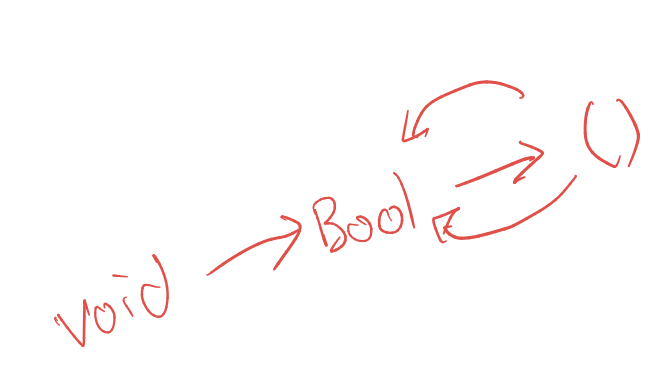  